In [1]:
import torch
from torch.autograd import grad

# Define the neural network architecture
class PINN(torch.nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = torch.nn.Linear(3, 50) # input: displacement, velocity, force; output: hidden layer with 50 nodes
        self.fc2 = torch.nn.Linear(50, 50) # hidden layer with 50 nodes; output: hidden layer with 50 nodes
        self.fc3 = torch.nn.Linear(50, 1) # hidden layer with 50 nodes; output: displacement

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Define the loss function
def PINN_loss(model, x_data, y_data):
    x = torch.tensor(x_data, dtype=torch.float32, requires_grad=True)
    y = torch.tensor(y_data, dtype=torch.float32, requires_grad=True)
    x.requires_grad = True

    # Compute the predicted displacement
    u_pred = model(x)

    # Compute the partial derivatives of u_pred with respect to x
    u_x = grad(u_pred, x, grad_outputs=torch.ones_like(u_pred), create_graph=True, retain_graph=True)[0]

    # Compute the residual, which should be zero if the model satisfies the equation of motion
    f = u_x + 1.0 * u_pred - 0.5

    # Compute the mean squared error between the predicted displacement and the true displacement
    mse = torch.mean((u_pred - y)**2)

    # Compute the mean squared error of the residual
    mse_res = torch.mean(f**2)

    # Combine the two losses with a weighting factor
    loss = mse + 100.0 * mse_res

    return loss

# Define the training loop
def train_PINN(model, x_data, y_data, num_epochs, optimizer):
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = PINN_loss(model, x_data, y_data)
        loss.backward()
        optimizer.step()
        if epoch % 1000 == 0:
            print("Epoch {}/{}: Loss = {:.6f}".format(epoch, num_epochs, loss.item()))

# Generate the training data
x_data = torch.tensor([[0.0, 0.0, 0.5], [0.1, 0.0498, 0.5], [0.2, 0.1959, 0.5], [0.3, 0.4285, 0.5], [0.4, 0.7245, 0.5], [0.5, 1.0625, 0.5], [0.6, 1.4238, 0.5], [0.7, 1.7916, 0.5], [0.8, 2.1517, 0.5], [0.9, 2.4916, 0.5], [1.0, 2.8008, 0.5]])
y_data = torch.tensor([0.0, 0.0498, 0.1959, 0.4285, 0.7245, 1.0625, 1.4238, 1.7916, 2.1517, 2.4916, 2.8008])
# Create an instance of the PINN model
model = PINN()

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10000
train_PINN(model, x_data, y_data, num_epochs, optimizer)

# Test the model
test_x = torch.tensor([[1.1, 2.8008, 0.5], [1.2, 3.0893, 0.5], [1.3, 3.3663, 0.5], [1.4, 3.6306, 0.5], [1.5, 3.8806, 0.5], [1.6, 4.1146, 0.5], [1.7, 4.3316, 0.5], [1.8, 4.5305, 0.5], [1.9, 4.7101, 0.5], [2.0, 4.8693, 0.5]])
with torch.no_grad():
    test_y = model(test_x).numpy()

# Print the results
print("Predicted displacement:")
print(test_y)



C:\Users\Tanmay\AppData\Local\Temp\ipykernel_3652\1658395954.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x_data, dtype=torch.float32, requires_grad=True)
C:\Users\Tanmay\AppData\Local\Temp\ipykernel_3652\1658395954.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y_data, dtype=torch.float32, requires_grad=True)


Epoch 0/10000: Loss = 51.928066
Epoch 1000/10000: Loss = 1.354338
Epoch 2000/10000: Loss = 1.342223
Epoch 3000/10000: Loss = 1.345310
Epoch 4000/10000: Loss = 1.335073
Epoch 5000/10000: Loss = 1.320607
Epoch 6000/10000: Loss = 1.335681
Epoch 7000/10000: Loss = 1.303086
Epoch 8000/10000: Loss = 1.300020
Epoch 9000/10000: Loss = 1.335891
Predicted displacement:
[[0.51360446]
 [0.5109881 ]
 [0.5165833 ]
 [0.5217947 ]
 [0.5331245 ]
 [0.5492152 ]
 [0.5638278 ]
 [0.5768669 ]
 [0.588228  ]
 [0.59660995]]


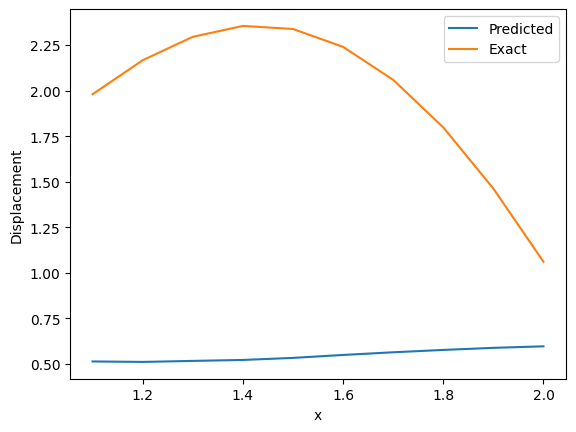

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Define the exact solution of the spring-mass system
def exact_solution(x):
    omega = np.sqrt(2.0)
    return x[:, 1] / omega * np.sin(omega * x[:, 0])

# Evaluate the exact solution on the test data
exact_y = exact_solution(test_x.numpy())

# Plot the predicted and exact displacement values
plt.plot(test_x[:, 0], test_y, label='Predicted')
plt.plot(test_x[:, 0], exact_y, label='Exact')
plt.xlabel('x')
plt.ylabel('Displacement')
plt.legend()
plt.show()
